# Neurite11 Dataset Exploration

This notebook provides exploratory data analysis (EDA) of the Neurite11
dataset (Kasthuri et al. 2015, "kasthuri11") at 6×6×30 nm — the same
resolution as SNEMI3D.

The download script produces a **single train crop** covering the full
annotated cylinder (5000×2900×300 voxels):

| Split | Origin (X, Y, Z) | Size | Notes |
|---|---|---|---|
| train01 | (3000, 7200, 950) | 5000×2900×300 | Full annotated cylinder |

File names: `neurite11_5000x2900x300_x3000_y7200_z950_{volume,segmentation}.h5`

## Contents
1. Load subvolume (EM + segmentation)
2. Visualize XY slices
3. Visualize XZ slices (anisotropy check)
4. Segmentation label statistics
5. Spatial layout of crop (2D footprint)
6. Instance size distribution

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

matplotlib.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

%matplotlib inline

## 1. Load Subvolume

Neurite11 (Kasthuri et al. 2015) at 6 × 6 × 30 nm (same as SNEMI3D).

```bash
python scripts/download_snemi3d.py --source neurite11
```

Files produced (2 total — 1 EM + 1 segmentation, 5000×2900×300):
```
neurite11_5000x2900x300_x3000_y7200_z950_{volume,segmentation}.h5    # train01
```

In [2]:
DATA_ROOT = Path('../data/SNEMI3D')

SPLITS = {
    'train01': (3000, 7200, 950),
}

CROP_X = 5000
CROP_Y = 2900
CROP_Z = 300

def vol_name(x, y, z, kind):
    return f'neurite11_{CROP_X}x{CROP_Y}x{CROP_Z}_x{x}_y{y}_z{z}_{kind}.h5'

def load_h5(path):
    with h5py.File(path, 'r', locking=False) as f:
        return f['main'][()]

volumes = {}
for name, (x, y, z) in SPLITS.items():
    em_path = DATA_ROOT / vol_name(x, y, z, 'volume')
    seg_path = DATA_ROOT / vol_name(x, y, z, 'segmentation')
    if em_path.exists() and seg_path.exists():
        em = load_h5(em_path)
        seg = load_h5(seg_path)
        volumes[name] = {'em': em, 'seg': seg, 'origin': (x, y, z)}
        print(f'{name}: em={em.shape} {em.dtype}  seg={seg.shape} {seg.dtype}  '
              f'ids={len(np.unique(seg))}  origin=({x},{y},{z})')
    else:
        print(f'{name}: NOT FOUND — run: python scripts/download_snemi3d.py --source neurite11')

print(f'\nLoaded {len(volumes)}/{len(SPLITS)} volumes')

train01: em=(300, 2900, 5000) uint8  seg=(300, 2900, 5000) uint64  ids=3999  origin=(3000,7200,950)

Loaded 1/1 volumes


## 2. Visualize XY Slices

Mid-Z slice from the train01 crop.  EM on top, coloured segmentation below.

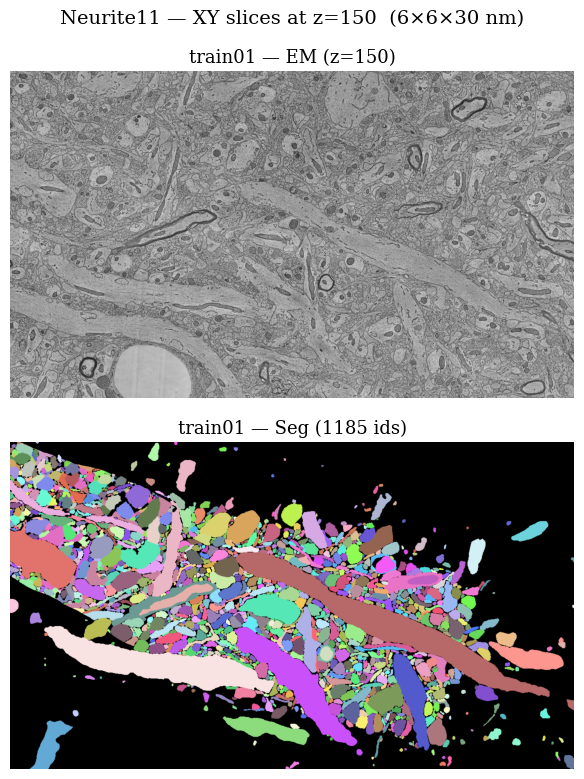

In [3]:
def colorize_seg(seg_slice):
    """Map integer labels to random colours (deterministic per ID)."""
    ids = np.unique(seg_slice)
    rgb = np.zeros((*seg_slice.shape, 3), dtype=np.float32)
    rng = np.random.RandomState(42)
    for uid in ids:
        if uid == 0:
            continue
        rgb[seg_slice == uid] = rng.rand(3) * 0.7 + 0.3
    return rgb

names = [n for n in SPLITS if n in volumes]
n = len(names)
if n > 0:
    z_mid = CROP_Z // 2
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 8))
    if n == 1:
        axes = axes[:, np.newaxis]

    for i, name in enumerate(names):
        v = volumes[name]
        em_slice = v['em'][z_mid]
        seg_slice = v['seg'][z_mid]

        axes[0, i].imshow(em_slice, cmap='gray', aspect='equal')
        axes[0, i].set_title(f'{name} — EM (z={z_mid})')
        axes[0, i].axis('off')

        axes[1, i].imshow(colorize_seg(seg_slice), aspect='equal')
        axes[1, i].set_title(f'{name} — Seg ({len(np.unique(seg_slice))} ids)')
        axes[1, i].axis('off')

    fig.suptitle(f'Neurite11 — XY slices at z={z_mid}  (6×6×30 nm)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 3. Visualize XZ Slices (Anisotropy Check)

The data is highly anisotropic: 6×6 nm in XY vs 30 nm in Z (5:1 ratio).
XZ slices show the characteristic elongation in the Z axis.

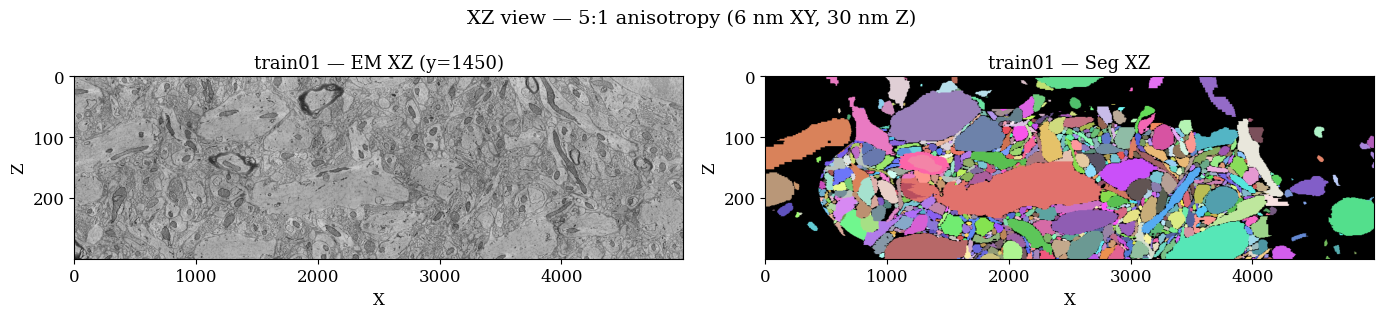

In [4]:
if volumes:
    name = names[0]
    v = volumes[name]
    y_mid = CROP_Y // 2

    em_xz = v['em'][:, y_mid, :]   # (Z, X)
    seg_xz = v['seg'][:, y_mid, :]

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))

    axes[0].imshow(em_xz, cmap='gray', aspect=5)
    axes[0].set_title(f'{name} — EM XZ (y={y_mid})')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Z')

    axes[1].imshow(colorize_seg(seg_xz), aspect=5)
    axes[1].set_title(f'{name} — Seg XZ')
    axes[1].set_xlabel('X')
    axes[1].set_ylabel('Z')

    fig.suptitle('XZ view — 5:1 anisotropy (6 nm XY, 30 nm Z)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Segmentation Label Statistics

Per-split summary: number of unique IDs, background fraction,
and whether any splits have empty (all-zero) segmentation.

In [5]:
if volumes:
    print(f'{"Split":<10} {"IDs":>6} {"BG %":>8} {"Min ID":>8} {"Max ID":>12} {"Empty slices":>14}')
    print('-' * 62)
    for name in names:
        seg = volumes[name]['seg']
        ids = np.unique(seg)
        n_ids = len(ids[ids > 0])
        bg_frac = (seg == 0).sum() / seg.size * 100
        empty_slices = sum(1 for z in range(seg.shape[0]) if seg[z].max() == 0)
        print(f'{name:<10} {n_ids:>6} {bg_frac:>7.1f}% {ids.min():>8} {ids.max():>12} {empty_slices:>14}')

Split         IDs     BG %   Min ID       Max ID   Empty slices
--------------------------------------------------------------


train01      3998    58.4%        0         6706              0


## 5. Spatial Layout of Crop

2D footprint of the train01 crop within the kasthuri11 annotated cylinder.
The crop covers 5000×2900 voxels starting at (3000, 7200).

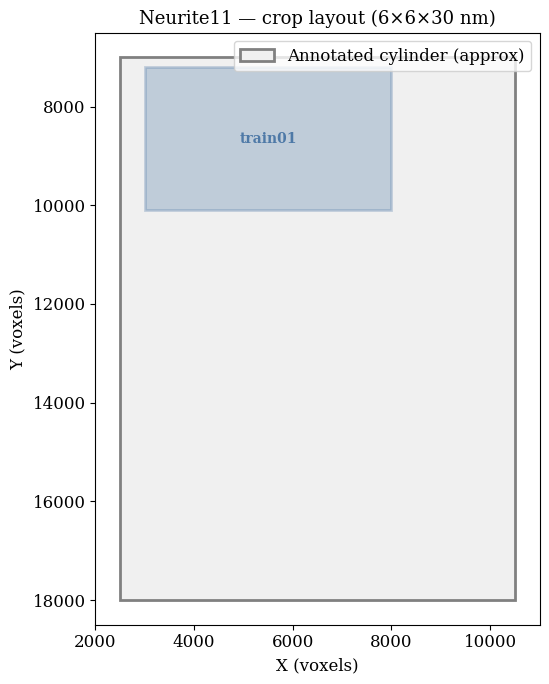

In [6]:
ANNOT_X, ANNOT_Y = 8000, 11000
ANNOT_OX, ANNOT_OY = 2500, 7000

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_xlim(ANNOT_OX - 500, ANNOT_OX + ANNOT_X + 500)
ax.set_ylim(ANNOT_OY + ANNOT_Y + 500, ANNOT_OY - 500)
ax.set_aspect('equal')
ax.set_xlabel('X (voxels)')
ax.set_ylabel('Y (voxels)')
ax.set_title('Neurite11 — crop layout (6×6×30 nm)')

ax.add_patch(mpatches.Rectangle((ANNOT_OX, ANNOT_OY), ANNOT_X, ANNOT_Y,
             linewidth=2, edgecolor='gray', facecolor='#f0f0f0',
             label='Annotated cylinder (approx)'))

colors = {'train01': '#4e79a7'}

for name, (x, y, z) in SPLITS.items():
    c = colors.get(name, '#999999')
    loaded = name in volumes
    ax.add_patch(mpatches.Rectangle(
        (x, y), CROP_X, CROP_Y,
        linewidth=2, edgecolor=c,
        facecolor=c, alpha=0.3 if loaded else 0.1,
    ))
    ax.text(x + CROP_X / 2, y + CROP_Y / 2, name,
            ha='center', va='center', fontsize=10, fontweight='bold', color=c)

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Instance Size Distribution

Histogram of instance sizes (voxel counts) in the train01 volume.
Useful for choosing `min_foreground` and `min_voxels` thresholds.

Total instances (train): 3998
  min:              16 voxels
  median:       85,704 voxels
  mean:        452,479 voxels
  max:     101,088,192 voxels
  < 100:             6 instances
  < 1000:           39 instances


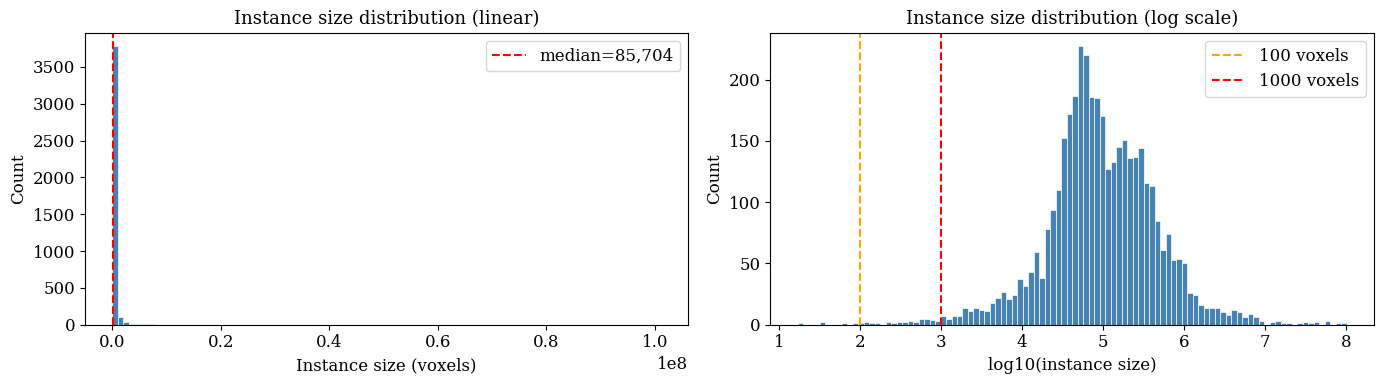

In [7]:
if volumes:
    all_sizes = []
    for name in names:
        if not name.startswith('train'):
            continue
        seg = volumes[name]['seg']
        ids, counts = np.unique(seg, return_counts=True)
        mask = ids > 0
        all_sizes.extend(counts[mask].tolist())

    all_sizes = np.array(all_sizes)
    print(f'Total instances (train): {len(all_sizes)}')
    print(f'  min:    {all_sizes.min():>12,} voxels')
    print(f'  median: {int(np.median(all_sizes)):>12,} voxels')
    print(f'  mean:   {int(all_sizes.mean()):>12,} voxels')
    print(f'  max:    {all_sizes.max():>12,} voxels')
    print(f'  < 100:  {(all_sizes < 100).sum():>12,} instances')
    print(f'  < 1000: {(all_sizes < 1000).sum():>12,} instances')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(all_sizes, bins=100, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[0].set_xlabel('Instance size (voxels)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Instance size distribution (linear)')
    axes[0].axvline(np.median(all_sizes), color='red', linestyle='--', label=f'median={int(np.median(all_sizes)):,}')
    axes[0].legend()

    axes[1].hist(np.log10(all_sizes + 1), bins=100, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[1].set_xlabel('log10(instance size)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Instance size distribution (log scale)')
    axes[1].axvline(np.log10(100), color='orange', linestyle='--', label='100 voxels')
    axes[1].axvline(np.log10(1000), color='red', linestyle='--', label='1000 voxels')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 7. EM Intensity Distribution

Per-split intensity histograms — useful for checking contrast consistency
across different XY tiles and whether normalisation is needed.

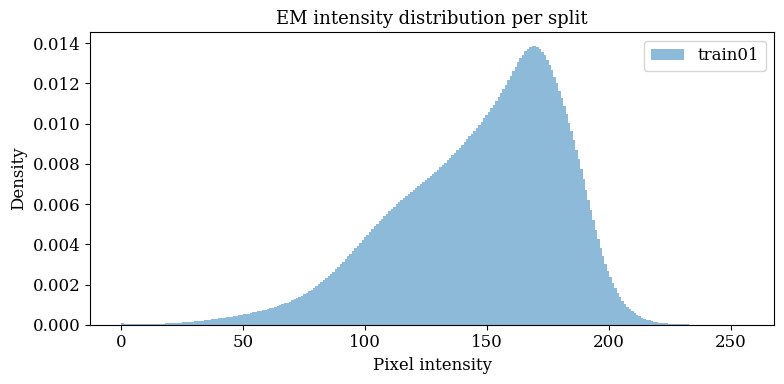

In [8]:
if volumes:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    for name in names:
        em = volumes[name]['em'].ravel()
        ax.hist(em, bins=256, range=(0, 255), alpha=0.5, density=True, label=name)
    ax.set_xlabel('Pixel intensity')
    ax.set_ylabel('Density')
    ax.set_title('EM intensity distribution per split')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Zoomed-In Detail

512×512 crop from the center of train01, showing fine neurite structure
at 6×6 nm resolution (same as SNEMI3D).

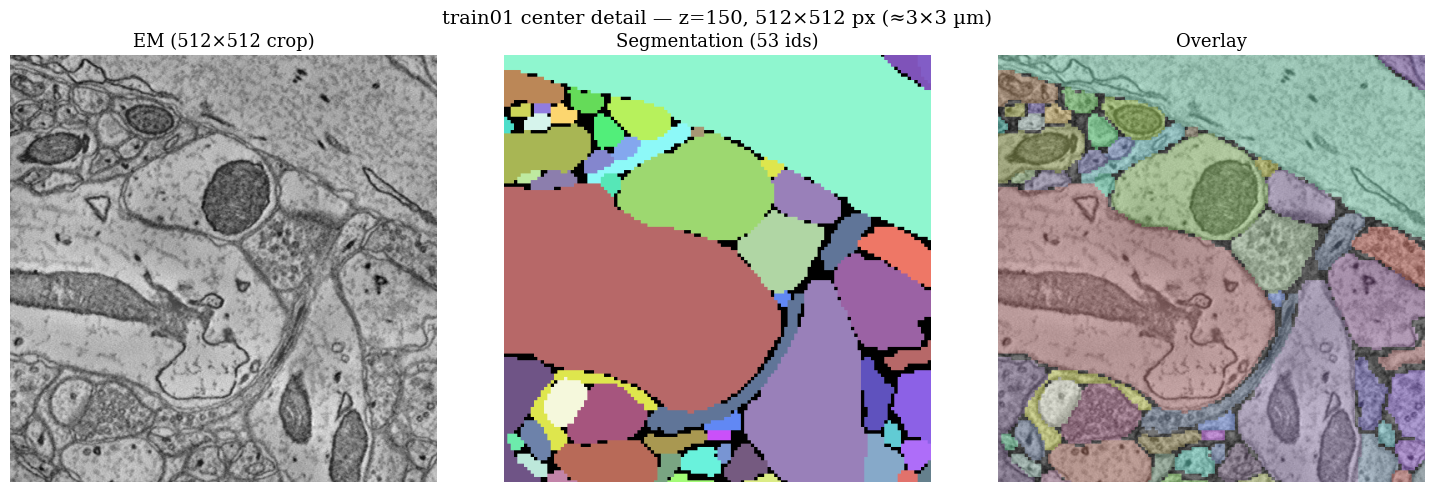

: 

In [ ]:
if 'train01' in volumes:
    v = volumes['train01']
    z_mid = CROP_Z // 2
    cx, cy = CROP_X // 2, CROP_Y // 2
    hw = 256

    em_crop = v['em'][z_mid, cy - hw:cy + hw, cx - hw:cx + hw]
    seg_crop = v['seg'][z_mid, cy - hw:cy + hw, cx - hw:cx + hw]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(em_crop, cmap='gray', aspect='equal')
    axes[0].set_title('EM (512×512 crop)')
    axes[0].axis('off')

    axes[1].imshow(colorize_seg(seg_crop), aspect='equal')
    axes[1].set_title(f'Segmentation ({len(np.unique(seg_crop))} ids)')
    axes[1].axis('off')

    # Overlay
    axes[2].imshow(em_crop, cmap='gray', aspect='equal')
    seg_rgb = colorize_seg(seg_crop)
    seg_rgb[seg_crop == 0] = 0
    axes[2].imshow(seg_rgb, alpha=0.4, aspect='equal')
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    fig.suptitle(f'train01 center detail — z={z_mid}, 512×512 px (≈3×3 µm)', fontsize=14)
    plt.tight_layout()
    plt.show()